# Download e visão inicial dos dados

In [20]:
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

In [42]:
symbol = 'MSFT'
start_date = '2024-01-01'
end_date = '2025-10-31'

df = yf.download(symbol, start=start_date, end=end_date)
df.to_csv('MSFT.csv')

/var/folders/22/p5w3pds139513tzr6pglg5_00000gn/T/ipykernel_874/3895409455.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(symbol, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


In [22]:
print('df info:')
print(df.info)

print(f'is there any NaN?: {df.isnull().any().any()}')


df info:
<bound method DataFrame.info of Price            Close        High         Low        Open    Volume
Ticker            MSFT        MSFT        MSFT        MSFT      MSFT
Date                                                                
2024-01-02  365.421570  370.377673  361.381797  368.367634  25258600
2024-01-03  365.155609  367.776535  363.096316  363.588971  23083500
2024-01-04  362.534668  367.618867  361.775991  365.224573  20901500
2024-01-05  362.347412  366.594092  361.115776  363.549490  21004600
2024-01-08  369.185516  369.688034  363.588967  363.874685  23134000
...                ...         ...         ...         ...       ...
2025-10-24  522.631836  524.368576  519.737290  521.813360  15532400
2025-10-27  530.527100  533.581381  528.021779  530.786624  18734700
2025-10-28  541.057373  552.685573  539.759814  548.972552  29986700
2025-10-29  540.538330  545.249544  535.727327  543.922012  36023000
2025-10-30  524.777832  533.970588  521.144617  529.488985  41

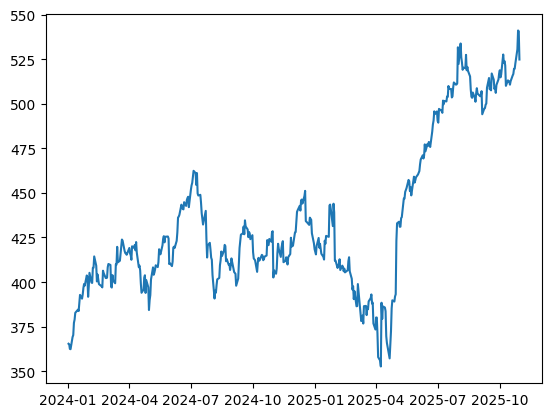

In [23]:
plt.plot(df['Close'])

In [24]:
print('df columns:')
print(df.columns)


df columns:
MultiIndex([( 'Close', 'MSFT'),
            (  'High', 'MSFT'),
            (   'Low', 'MSFT'),
            (  'Open', 'MSFT'),
            ('Volume', 'MSFT')],
           names=['Price', 'Ticker'])


In [25]:
# tirando o segundo nível das colunas
df.columns = df.columns.get_level_values('Price')
df

Price,Close,High,Low,Open,Volume
Date,,,,,
2024-01-02,365.421570,370.377673,361.381797,368.367634,25258600
2024-01-03,365.155609,367.776535,363.096316,363.588971,23083500
2024-01-04,362.534668,367.618867,361.775991,365.224573,20901500
2024-01-05,362.347412,366.594092,361.115776,363.549490,21004600
2024-01-08,369.185516,369.688034,363.588967,363.874685,23134000
...,...,...,...,...,...
2025-10-24,522.631836,524.368576,519.737290,521.813360,15532400
2025-10-27,530.527100,533.581381,528.021779,530.786624,18734700
2025-10-28,541.057373,552.685573,539.759814,548.972552,29986700


In [26]:
df.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')

# Tratando outliers

In [27]:
# Criando função para tratar outliers

def cap_outliers(df, cols, factor=1.5):
    df = df.copy()
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - factor * IQR
        upper = Q3 + factor * IQR
        print(f'{col} limits: lower: {lower} upper: {upper}')

        df[col] = df[col].clip(lower, upper) #Valores menores que lower são substituídos por lower. Valores maiores que upper são substituídos por upper. Mantém o tamanho do DataFrame → essencial para LSTM. Evita excluir linhas e quebrar a sequência temporal.
    return df


In [28]:
df_sem_outliers = cap_outliers(df, df.columns)

Close limits: lower: 330.4282531738281 upper: 530.8386535644531
High limits: lower: 333.7919071306504 upper: 533.821880990002
Low limits: lower: 325.9742536288652 upper: 528.8090643714877
Open limits: lower: 331.7281259364536 upper: 527.5596922956463
Volume limits: lower: 5844875.0 upper: 33769275.0


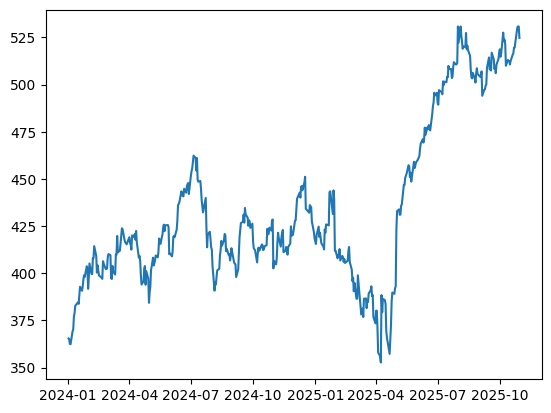

In [29]:
plt.plot(df_sem_outliers['Close'])

# Transformando Dados

In [30]:
# para LSTM (treino = passado / teste = futuro), você separa X e y depois de criar as janelas (windows).

train_size = int(len(df_sem_outliers) * 0.8)

train = df_sem_outliers.iloc[:train_size]
test  = df_sem_outliers.iloc[train_size:]


In [31]:
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train)
test_scaled  = scaler.transform(test)


In [37]:
print(f"transformed shape: {train.shape}")
print(f"per-feature minimum before scaling: \n {train.min(axis=0)}")
print(f"per-feature maximum before scaling: \n {train.max(axis=0)}")
print(f"per-feature minimum after scaling: \n {train_scaled.min(axis=0)}")
print(f"per-feature maximum after scaling: \n {train_scaled.max(axis=0)}")

transformed shape: (368, 5)
per-feature minimum before scaling: 
 Price
Close     3.526694e+02
High      3.625365e+02
Low       3.429515e+02
Open      3.490090e+02
Volume    7.164500e+06
dtype: float64
per-feature maximum before scaling: 
 Price
Close     4.785561e+02
High      4.817649e+02
Low       4.751980e+02
Open      4.805392e+02
Volume    3.376928e+07
dtype: float64
per-feature minimum after scaling: 
 [0. 0. 0. 0. 0.]
per-feature maximum after scaling: 
 [1. 1. 1. 1. 1.]


In [38]:
print(f"transformed shape: {test.shape}")
print(f"per-feature minimum before scaling: \n {test.min(axis=0)}")
print(f"per-feature maximum before scaling: \n {test.max(axis=0)}")
print(f"per-feature minimum after scaling: \n {test_scaled.min(axis=0)}")
print(f"per-feature maximum after scaling: \n {test_scaled.max(axis=0)}")

transformed shape: (92, 5)
per-feature minimum before scaling: 
 Price
Close     4.842960e+02
High      4.860398e+02
Low       4.708533e+02
Open      4.765333e+02
Volume    1.184660e+07
dtype: float64
per-feature maximum before scaling: 
 Price
Close     5.308387e+02
High      5.338219e+02
Low       5.288091e+02
Open      5.275597e+02
Volume    3.376928e+07
dtype: float64
per-feature minimum after scaling: 
 [1.04559525 1.0358553  0.96714698 0.9695437  0.17598721]
per-feature maximum after scaling: 
 [1.41531402 1.4366161  1.40538777 1.35748838 1.        ]


In [32]:
# Para LSTMs, você nunca usa “linha atual” como X — você usa um histórico (window).
# Exemplo: usar 30 passos passados para prever o próximo passo.

def create_sequences_multivar(data, window, target_col_index):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i, :])      # janela com as 5 features
        y.append(data[i, target_col_index]) # apenas o Close
    return np.array(X), np.array(y)


In [33]:
# Você deve criar as janelas separadamente, pois misturar test com train faz vazamento de dados.

window = 30
target_col_index = 0  # "Close"

X_train, y_train = create_sequences_multivar(train_scaled, window, target_col_index)
X_test, y_test   = create_sequences_multivar(test_scaled, window, target_col_index)

In [35]:
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (338, 30, 5)
y_train shape: (338,)
y_test shape: (62, 30, 5)
y_test shape: (62,)
